# BipedalWalker PPO

## 实验目标

本实验使用 `PPO` 训练 `BipedalWalker-v3` 的连续动作步态控制策略。目标是让双足机器人形成稳定步态、持续前进，并尽量减少无效摆动和跌倒。

## 为什么这里选择 PPO

`BipedalWalker-v3` 需要四个关节连续协调输出，状态维度更高、控制链条更长。`PPO` 在这类连续控制任务里通常更稳，也更适合用多进程并行环境提升采样效率。

In [1]:
import os
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import SubprocVecEnv, VecMonitor

In [2]:
ENV_ID = "BipedalWalker-v3"
AVAILABLE_CPUS = os.cpu_count() or 1
NUM_ENVS = min(24, max(8, AVAILABLE_CPUS))
TOTAL_TIMESTEPS = 1200000
N_STEPS = 1024
BATCH_SIZE = 1024
N_EPOCHS = 10
LEARNING_RATE = 3e-4
GAMMA = 0.99
GAE_LAMBDA = 0.95
CLIP_RANGE = 0.2
ENT_COEF = 0.001
VF_COEF = 0.5
MAX_GRAD_NORM = 0.5
EVAL_EPISODES = 60
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
MAX_STEPS = 1600
SUCCESS_THRESHOLD_RETURN = 200
SEED = 42
DEVICE = "cpu"

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

In [3]:
def make_env(rank, render_mode=None):
    def _init():
        env = gym.make(ENV_ID, render_mode=render_mode)
        env.reset(seed=SEED + rank)
        return Monitor(env)
    return _init

class EpisodeStatsCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_returns = []
        self.episode_lengths = []
        self.success_flags = []

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        dones = self.locals.get("dones", [])
        for done, info in zip(dones, infos):
            if done and "episode" in info:
                r = float(info["episode"]["r"])
                l = int(info["episode"]["l"])
                self.episode_returns.append(r)
                self.episode_lengths.append(l)
                self.success_flags.append(int(r >= SUCCESS_THRESHOLD_RETURN))
        return True

In [4]:
train_env = SubprocVecEnv([make_env(i) for i in range(NUM_ENVS)], start_method="fork")
train_env = VecMonitor(train_env)
callback = EpisodeStatsCallback()

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=LEARNING_RATE,
    n_steps=N_STEPS,
    batch_size=BATCH_SIZE,
    n_epochs=N_EPOCHS,
    gamma=GAMMA,
    gae_lambda=GAE_LAMBDA,
    clip_range=CLIP_RANGE,
    ent_coef=ENT_COEF,
    vf_coef=VF_COEF,
    max_grad_norm=MAX_GRAD_NORM,
    policy_kwargs=dict(net_arch=dict(pi=[256, 256], vf=[256, 256])),
    verbose=0,
    seed=SEED,
    device=DEVICE,
)

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback, progress_bar=False)
train_env.close()

/opt/anaconda3/lib/python3.13/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


In [5]:
episode_return_series = pd.Series(callback.episode_returns, dtype=float)
episode_length_series = pd.Series(callback.episode_lengths, dtype=float)
success_series = pd.Series(callback.success_flags, dtype=float)
rolling_return = episode_return_series.rolling(50).mean() if len(episode_return_series) >= 50 else episode_return_series
rolling_success = success_series.rolling(50).mean() if len(success_series) >= 50 else success_series
rolling_length = episode_length_series.rolling(50).mean() if len(episode_length_series) >= 50 else episode_length_series

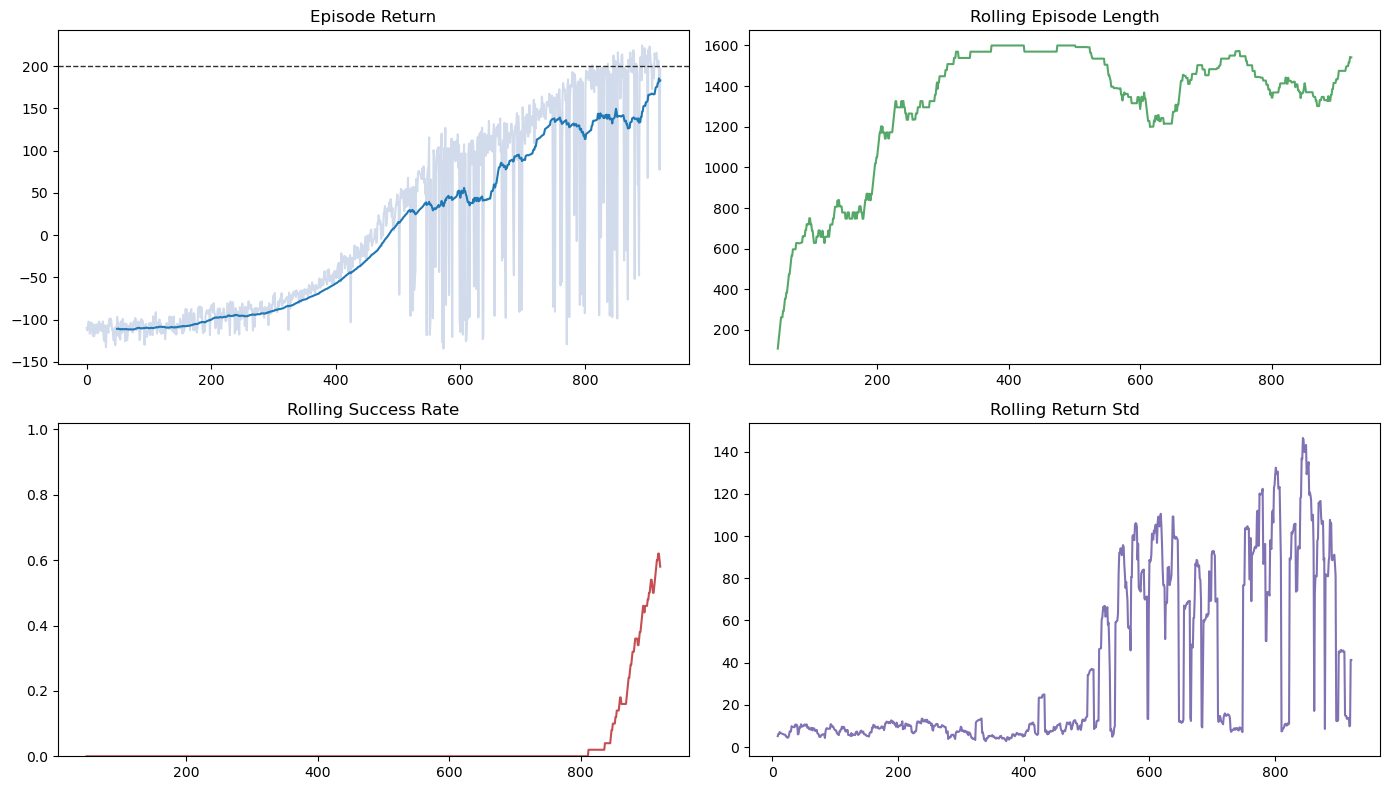

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(callback.episode_returns, alpha=0.25, color="#4c72b0")
axes[0, 0].plot(rolling_return, color="#1f77b4")
axes[0, 0].axhline(SUCCESS_THRESHOLD_RETURN, linestyle="--", color="#2f2f2f", linewidth=1)
axes[0, 0].set_title("Episode Return")
axes[0, 1].plot(rolling_length, color="#55a868")
axes[0, 1].set_title("Rolling Episode Length")
axes[1, 0].plot(rolling_success, color="#c44e52")
axes[1, 0].set_ylim(0, 1.02)
axes[1, 0].set_title("Rolling Success Rate")
axes[1, 1].plot(pd.Series(callback.episode_returns).rolling(10).std(), color="#8172b3")
axes[1, 1].set_title("Rolling Return Std")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ppo_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
eval_returns = []
eval_successes = []
eval_final_hull_angle = []
eval_mean_abs_actions = []
for episode in range(EVAL_EPISODES):
    eval_env = gym.make(ENV_ID)
    obs, info = eval_env.reset(seed=SEED + 10000 + episode)
    total_reward = 0.0
    actions = []
    for step in range(MAX_STEPS):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        actions.append(float(np.mean(np.abs(action))))
        if terminated or truncated:
            break
    eval_returns.append(total_reward)
    eval_successes.append(int(total_reward >= SUCCESS_THRESHOLD_RETURN))
    eval_final_hull_angle.append(float(obs[0]))
    eval_mean_abs_actions.append(float(np.mean(actions)))
    eval_env.close()

eval_results = pd.DataFrame({"evaluation_return": eval_returns, "success": eval_successes, "final_hull_angle": eval_final_hull_angle, "mean_abs_action": eval_mean_abs_actions})
eval_results.head()

,evaluation_return,success,final_hull_angle,mean_abs_action
0,-29.009483,0,-1.588600,0.414787
1,281.839050,1,-0.269970,0.432149
2,176.262115,0,-1.541538,0.427956
3,282.677765,1,0.080577,0.459493
4,262.492340,1,0.251311,0.440463


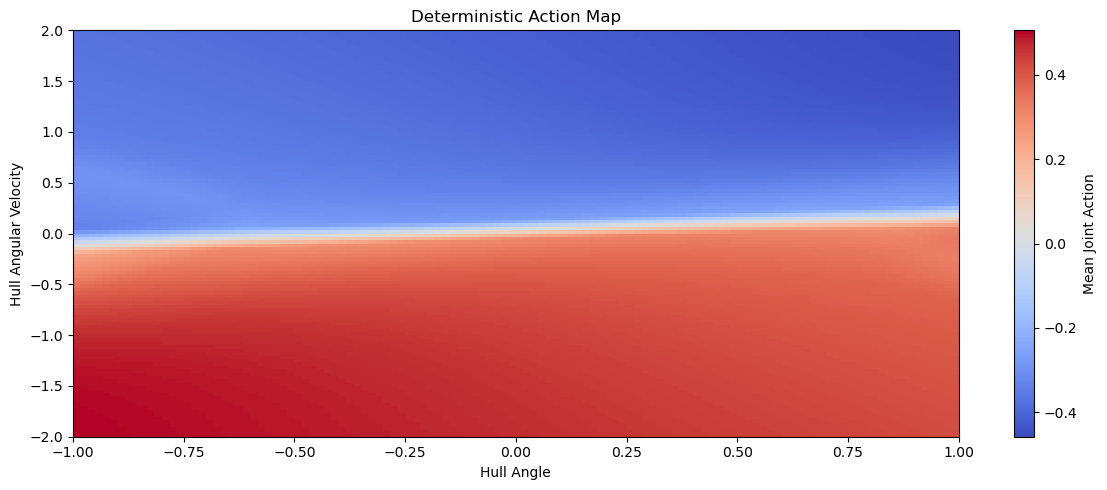

In [8]:
hull_values = np.linspace(-1.0, 1.0, 120)
vel_values = np.linspace(-2.0, 2.0, 120)
action_grid = np.zeros((len(vel_values), len(hull_values)))
for i, vel in enumerate(vel_values):
    for j, hull in enumerate(hull_values):
        obs = np.zeros(24, dtype=np.float32)
        obs[0] = hull
        obs[1] = vel
        action, _ = model.predict(obs, deterministic=True)
        action_grid[i, j] = float(np.mean(action))
plt.figure(figsize=(12, 5))
plt.imshow(action_grid, extent=[hull_values[0], hull_values[-1], vel_values[0], vel_values[-1]], origin="lower", aspect="auto", cmap="coolwarm")
plt.colorbar(label="Mean Joint Action")
plt.title("Deterministic Action Map")
plt.xlabel("Hull Angle")
plt.ylabel("Hull Angular Velocity")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ppo_policy_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 20000 + rollout_idx)
    frames = []
    total_reward = 0.0
    actions = []
    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = rollout_env.step(action)
        total_reward += reward
        actions.append(float(np.mean(np.abs(action))))
        if terminated or truncated:
            break
    final_frame = rollout_env.render()
    if final_frame is not None:
        frames.extend([final_frame] * 20)
    rollout_summaries.append({"rollout_index": rollout_idx + 1, "seed": SEED + 20000 + rollout_idx, "total_reward": float(total_reward), "episode_length": step + 1, "final_hull_angle": float(obs[0]), "mean_abs_action": float(np.mean(actions)), "success": int(total_reward >= SUCCESS_THRESHOLD_RETURN)})
    if frames:
        imageio.mimsave(RESULTS_DIR / f"ppo_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)
    rollout_env.close()

pd.DataFrame(rollout_summaries)

,rollout_index,seed,total_reward,episode_length,final_hull_angle,mean_abs_action,success
0,1,20042,162.973053,1595,-1.740481,0.446146,0
1,2,20043,285.554901,1594,-0.068439,0.438384,1
2,3,20044,287.171021,1579,0.154697,0.431333,1


In [10]:
metrics = pd.DataFrame({"metric": ["device", "num_envs", "total_timesteps", "recent_episode_return_last_50", "recent_episode_length_last_50", "recent_success_rate_last_50", "evaluation_average_return", "evaluation_return_std", "evaluation_success_rate", "evaluation_average_final_hull_angle", "evaluation_average_mean_abs_action"], "value": [DEVICE, NUM_ENVS, TOTAL_TIMESTEPS, float(episode_return_series.tail(50).mean()) if len(episode_return_series) > 0 else 0.0, float(episode_length_series.tail(50).mean()) if len(episode_length_series) > 0 else 0.0, float(success_series.tail(50).mean()) if len(success_series) > 0 else 0.0, float(np.mean(eval_returns)), float(np.std(eval_returns)), float(np.mean(eval_successes)), float(np.mean(eval_final_hull_angle)), float(np.mean(eval_mean_abs_actions))]})
metrics

,metric,value
0,device,cpu
1,num_envs,24
2,total_timesteps,1200000
3,recent_episode_return_last_50,182.756002
4,recent_episode_length_last_50,1541.24
5,recent_success_rate_last_50,0.58
6,evaluation_average_return,214.302948
7,evaluation_return_std,111.587242
8,evaluation_success_rate,0.716667
9,evaluation_average_final_hull_angle,-0.195189


In [11]:
episode_summary = pd.DataFrame({"episode_return": callback.episode_returns, "episode_length": callback.episode_lengths, "success": callback.success_flags})
episode_summary.to_csv(RESULTS_DIR / "ppo_episode_summary.csv", index=False)
eval_results.to_csv(RESULTS_DIR / "ppo_eval_results.csv", index=False)
metrics.to_csv(RESULTS_DIR / "ppo_metrics.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "ppo_rollout_summary.csv", index=False)
print(metrics.to_string(index=False))

                             metric       value
                             device         cpu
                           num_envs          24
                    total_timesteps     1200000
      recent_episode_return_last_50  182.756002
      recent_episode_length_last_50     1541.24
        recent_success_rate_last_50        0.58
          evaluation_average_return  214.302948
              evaluation_return_std  111.587242
            evaluation_success_rate    0.716667
evaluation_average_final_hull_angle   -0.195189
 evaluation_average_mean_abs_action    0.437128
